In [1]:
!mkdir -p /content/online_retail
!unzip -o "/content/online+retail.zip" -d /content/online_retail

Archive:  /content/online+retail.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/online+retail.zip or
        /content/online+retail.zip.zip, and cannot find /content/online+retail.zip.ZIP, period.


In [2]:
!wget -O /content/Online_Retail.xlsx "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

--2026-10-08 17:00:33--  https://archive.ics.uci.edu/static/public/352/online+retail.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘/content/Online_Retail.xlsx’

/content/Online_Ret     [    <=>             ]  22.62M  26.4MB/s    in 0.9s    

2026-10-08 17:00:34 (26.4 MB/s) - ‘/content/Online_Retail.xlsx’ saved [23715478]



In [3]:
!mkdir -p /content/online_retail
!unzip -o /content/Online_Retail.xlsx -d /content/online_retail

Archive:  /content/Online_Retail.xlsx
 extracting: /content/online_retail/Online Retail.xlsx  


In [4]:
import pandas as pd

file_path = '/content/online_retail/Online Retail.xlsx'

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)


Dataset loaded successfully!
Shape: (541909, 8)


In [5]:
print("Column names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
print("Missing values:")
print(df.isnull().sum())

print("\nNegative quantities:")
print((df['Quantity'] < 0).sum())

print("\nZero or negative prices:")
print((df['UnitPrice'] <= 0).sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Negative quantities:
10624

Zero or negative prices:
2517

Duplicate rows:
5268


In [7]:
# Remove rows without CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove duplicate transactions
df = df.drop_duplicates()

# Keep only positive quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("Cleaned dataset shape:", df.shape)
print("Missing CustomerID:", df['CustomerID'].isnull().sum())
print("Negative quantities:", (df['Quantity'] < 0).sum())
print("Non-positive prices:", (df['UnitPrice'] <= 0).sum())

Cleaned dataset shape: (392692, 8)
Missing CustomerID: 0
Negative quantities: 0
Non-positive prices: 0


In [8]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print("TotalAmount column created successfully!")
display(df[['Quantity', 'UnitPrice', 'TotalAmount']].head())

TotalAmount column created successfully!


,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [9]:
import pandas as pd

# Set the reference date as one day after the last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

# Rename the columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("RFM analysis completed!")
print("Number of customers:", len(rfm))

display(rfm.head())

RFM analysis completed!
Number of customers: 4338


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [10]:
from sklearn.preprocessing import StandardScaler

# Standardize RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

print("RFM data standardized successfully!")
print("Scaled data shape:", rfm_scaled.shape)

RFM data standardized successfully!
Scaled data shape: (4338, 3)


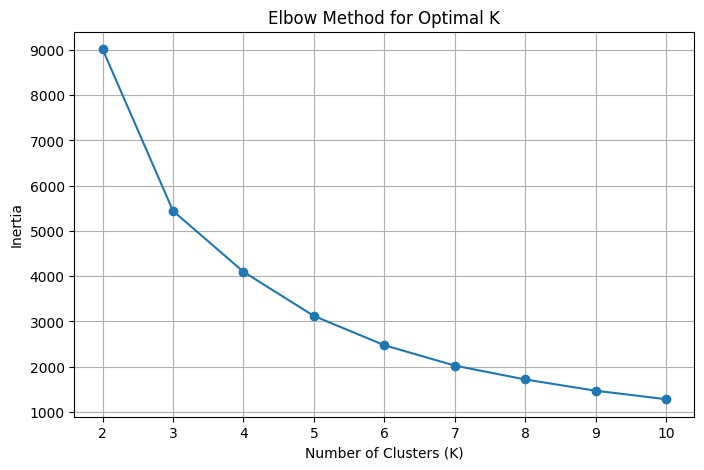

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [12]:
from sklearn.cluster import KMeans

# Create the final K-Means model with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Assign clusters to customers
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed successfully!")
print("\nCustomer count in each cluster:")
print(rfm['Cluster'].value_counts().sort_index())

K-Means clustering completed successfully!

Customer count in each cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


In [13]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

cluster_profile['CustomerCount'] = rfm['Cluster'].value_counts().sort_index()

print("Customer Segment Profile:")
display(cluster_profile)

Customer Segment Profile:


,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,43.70,3.68,1353.63,3054
1,248.08,1.55,478.85,1067
2,7.38,82.54,127187.96,13
3,15.50,22.33,12690.50,204


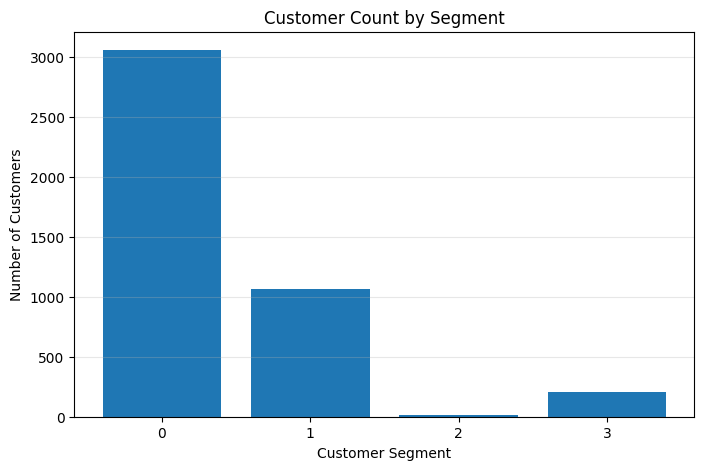

In [14]:
import matplotlib.pyplot as plt

cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Count by Segment')
plt.grid(axis='y', alpha=0.3)

plt.show()

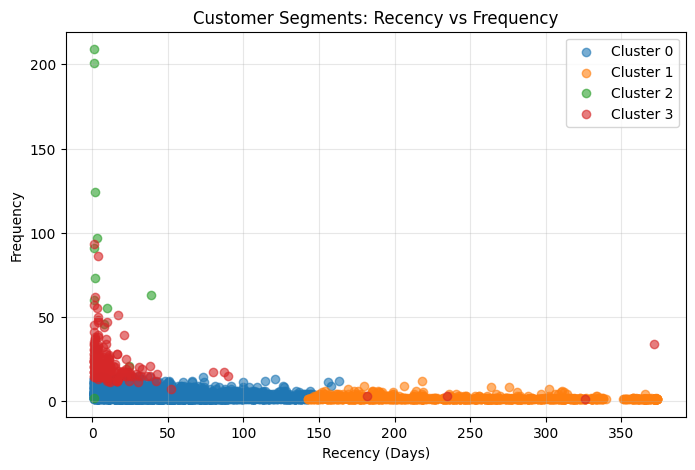

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for cluster in sorted(rfm['Cluster'].unique()):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    plt.scatter(
        cluster_data['Recency'],
        cluster_data['Frequency'],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.xlabel('Recency (Days)')
plt.ylabel('Frequency')
plt.title('Customer Segments: Recency vs Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

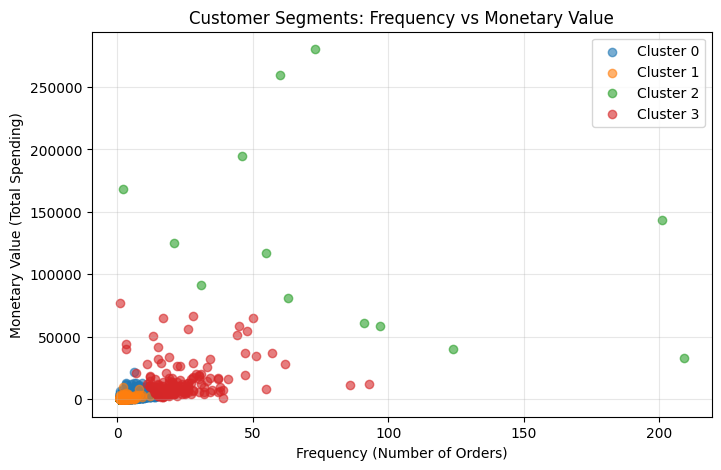

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for cluster in sorted(rfm['Cluster'].unique()):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    plt.scatter(
        cluster_data['Frequency'],
        cluster_data['Monetary'],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.xlabel('Frequency (Number of Orders)')
plt.ylabel('Monetary Value (Total Spending)')
plt.title('Customer Segments: Frequency vs Monetary Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Customer Segment Insights and Marketing Recommendations

1. VIP / High-Value Customers (Cluster 2)
- 13 customers
- Very recent purchases, very high order frequency, and extremely high spending.
- Recommendation: Provide VIP benefits, exclusive offers, early access to new products, and personalized rewards to retain these customers.

2. Loyal Customers (Cluster 3)
- 204 customers
- Recent purchases, high purchase frequency, and strong spending.
- Recommendation: Use loyalty programs, personalized product recommendations, and cross-selling offers to increase customer lifetime value.

3. Regular / Potential Customers (Cluster 0)
- 3,054 customers
- Moderate recency, frequency, and spending.
- Recommendation: Use targeted promotions, product recommendations, and incentives to encourage repeat purchases and move customers toward the loyal segment.

4. At-Risk / Inactive Customers (Cluster 1)
- 1,067 customers
- Long time since the last purchase, low frequency, and low spending.
- Recommendation: Use re-engagement campaigns, discounts, reminders, and personalized offers to encourage customers to return.

Conclusion

The customer segmentation analysis successfully grouped 4,338 customers into four distinct segments using RFM analysis and K-Means clustering.

The segments were identified as VIP/High-Value Customers, Loyal Customers, Regular/Potential Customers, and At-Risk/Inactive Customers. Each segment shows different purchasing behavior in terms of recency, frequency, and monetary value.

The segmentation can help businesses create targeted marketing strategies, improve customer retention, strengthen loyalty, and focus resources on high-value customers.